# 100 Hz deadtime explorer
Interactive filters to explore the 5D data without rendering every plot. This notebook ignores 10 Hz data and only uses 100 Hz entries, since earlier plots showed rate does not affect results.

In [1]:

from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from ipywidgets import interact, Dropdown
import sys

ROOT = Path.cwd().resolve().parent
sys.path.append(str(ROOT / 'src'))
from deadtime_analysis import DeadtimeAnalysis

EST_PATH = ROOT / 'data' / 'estimated_deadtime_all.json'
COMBINED = ROOT / 'data' / 'combined_deadtime.jsonl'

# Load estimates and filter to 100 Hz
with EST_PATH.open() as fh:
    estimates = json.load(fh)

est_df = pd.DataFrame(estimates)
est_df_100 = est_df[est_df['pulse_rate_hz'] == 100.0].copy()

# Load full data (100 Hz only)
analysis_full = DeadtimeAnalysis.from_jsonl([str(COMBINED)])
analysis_100 = analysis_full.df[analysis_full.df['pulse_rate_hz'] == 100.0].copy()

print('Estimates (100 Hz) rows:', len(est_df_100))
print('Data (100 Hz) rows:', len(analysis_100))


Estimates (100 Hz) rows: 126
Data (100 Hz) rows: 2016


## Heatmap overview (100 Hz)
Color = minimum multi-pulse separation (µs). One panel per pulse count.

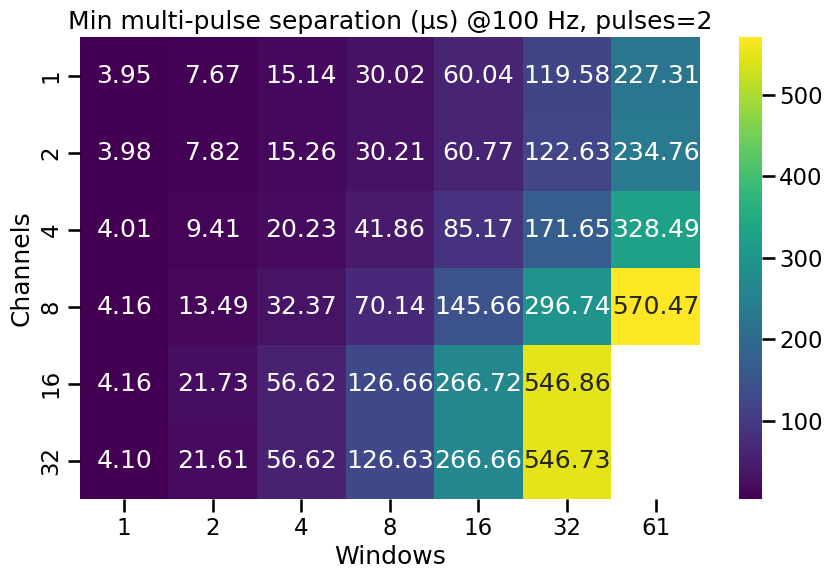

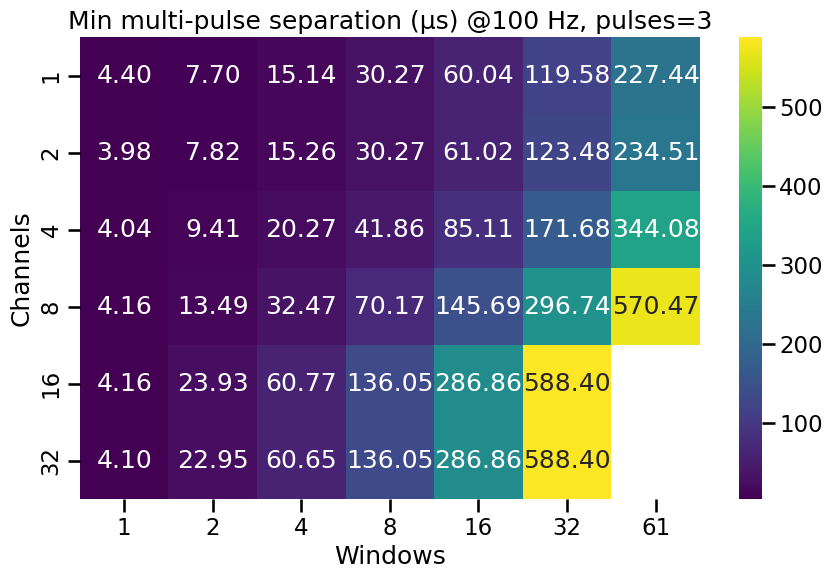

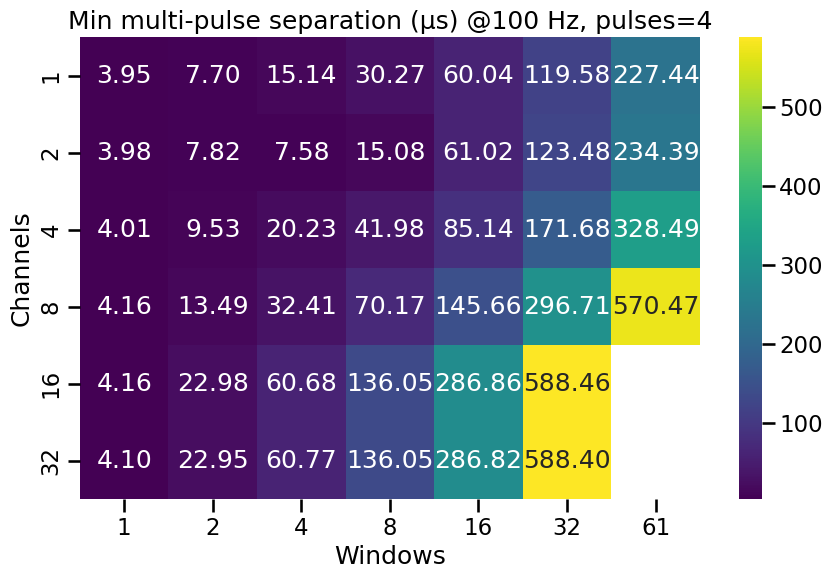

In [2]:

import seaborn as sns
sns.set_context('talk')

for n in sorted(est_df_100['num_pulses'].dropna().unique()):
    sub = est_df_100[est_df_100['num_pulses'] == n]
    if sub.empty:
        continue
    pivot = sub.pivot_table(index='channel_count', columns='windows', values='min_all_pulses_response_us')
    plt.figure(figsize=(10,6))
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='viridis')
    plt.title(f'Min multi-pulse separation (µs) @100 Hz, pulses={int(n)}')
    plt.xlabel('Windows')
    plt.ylabel('Channels')
    plt.show()


## Interactive slice
Select pulse count / channels / windows (all 100 Hz). Stars mark the response and lower-bound pair; Δ shows their difference.

In [4]:

# Build widget options from 100 Hz data
pulse_options = sorted(analysis_100['num_pulses'].dropna().unique())
channel_options = ['(all)'] + sorted(analysis_100['channel_count'].dropna().unique())
window_options = ['(all)'] + sorted(analysis_100['windows'].dropna().unique())

@interact(
    num_pulses=Dropdown(options=pulse_options, value=pulse_options[0], description='Pulses'),
    channels=Dropdown(options=channel_options, value='(all)', description='Channels'),
    windows=Dropdown(options=window_options, value='(all)', description='Windows'),
)
def _plot(num_pulses, channels, windows):
    df = analysis_100.copy()
    df = df[df['num_pulses'] == num_pulses]
    ch_val = None if channels == '(all)' else channels
    win_val = None if windows == '(all)' else windows
    if ch_val is not None:
        df = df[df['channel_count'] == ch_val]
    if win_val is not None:
        df = df[df['windows'] == win_val]
    if df.empty:
        print('No data for selection')
        return
    # Build estimate match for highlights
    match = None
    est_match = est_df_100[(est_df_100['num_pulses']==num_pulses)]
    if ch_val is not None:
        est_match = est_match[est_match['channel_count']==ch_val]
    if win_val is not None:
        est_match = est_match[est_match['windows']==win_val]
    if not est_match.empty:
        match = est_match.iloc[0]
    highlights = None
    text = None
    if match is not None:
        lb = match.get('min_all_pulses_lower_bound_ns')
        resp = match.get('min_all_pulses_response_ns')
        if lb is not None and resp is not None:
            highlights = [lb, resp]
            text = f"Δ = {(resp-lb)/1000.0:.3f} µs"
    ana = DeadtimeAnalysis(df, single_factor=analysis_full.single_factor, double_factor=analysis_full.double_factor)
    ana.plot_rate_vs_separation_by_channels(100.0, num_pulses=num_pulses)
    ana.plot_rate_vs_separation_by_windows(100.0, num_pulses=num_pulses)


interactive(children=(Dropdown(description='Pulses', options=(np.int64(2), np.int64(3), np.int64(4)), value=np…